# 카페 인 제주 (Caffe-IN Jeju) — 골든셋 검색 품질 평가

**프로젝트**: 유튜브·네이버 블로그의 원문 근거로 제주 카페를 추천하는 "근거 있는 검색엔진" — [jeju-bh6i.onrender.com](https://jeju-bh6i.onrender.com)

**평가 대상**: `app/server.py`의 `_search_core` — 배포본과 동일한 실서빙 검색 경로 (이름 사전 + 태그 번역 + 임베딩 폴백 + 지역 교정, 런타임 LLM 없음)

**이 노트북의 자리**: 발표(2026-07-10)에서 "Gold/Silver/Bronze 평가는 개편 전 측정 — 개편 후 재측정은 예정"이라고 공개한 각주를 갚는 마지막 작업. 측정으로 시작한 프로젝트를 측정으로 닫는다.

## 평가 원칙 (엄수)
1. **문항 동결** — 라벨링 전에 25문항을 고정한다 (아래 셀이 생성, 이미 라벨된 파일은 덮어쓰지 않음)
2. **오염 방지** — 정답 라벨링은 검색 시스템이 아니라 단순 필터로 카드를 대조한다 (평가 대상으로 정답을 찾으면 시험문제를 시험지로 채점하는 꼴)
3. **측정만 한다** — 점수가 낮아도 검색 코드는 수정하지 않고 그대로 기록한다
4. 지표는 **Hit@5 + MRR@10** 둘만, honest_zero는 별도 집계

## 실행 조건
- 레포 루트에서 주피터 실행, `.env`(OPENAI_KEY)와 chroma 인덱스(기본 `chroma_smoke/`) 필요
- 검색 1회당 임베딩 호출 1번뿐 — 25문항 전체 평가 비용은 무시 수준
- 순서: **① 문항 동결 → ② 라벨링 → ③ 평가 → ④ 시각화 → ⑤ README 반영**
- 어느 셀이든 순서가 어긋나면 빨간 오류 대신 "무엇을 먼저 하라"는 안내가 출력된다

## 1. 평가 설계

**지표 정의**
- **Hit@5** — "상위 5개 안에 정답이 하나라도 있으면 성공"인 문항의 비율. 사용자는 보통 첫 화면(5장)까지만 본다는 가정.
  예: "당근케이크 맛있는 카페"의 정답이 3위에 나오면 성공, 7위면 실패.
- **MRR@10** (Mean Reciprocal Rank) — "첫 정답이 몇 등에 나왔나"를 등수의 역수로 점수화한 평균. 1등=1.0, 2등=0.5, 5등=0.2, top10 밖=0.
  Hit@5가 "찾긴 했나"라면 MRR은 "얼마나 위에 올렸나".
- **honest_zero** — 정답이 실제로 존재하지 않는 질문(예: "24시간 하는 카페")에 0건이라고 정직하게 답하는지.
  억지로 아무 카페나 채우면 실패. "모르면 모른다"가 이 프로젝트의 정체성이라 별도 집계한다.

**문항 25개 구성**

| 출처 | 수 | 설명 |
|---|---|---|
| 동료 작성 (peer) | 10 | 카드 데이터를 보기 **전** 시점에 팀원이 작성 — 오염 없음 |
| 자체 작성 (self) | 15 | 지역조합 6 · 직접 4 · 무드 2 · 밀도 1 · honest_zero 2 — 데이터 접촉자 작성 (한계에 명시) |

동료 vs 자체 점수 차이는 그 자체로 **자기확인 편향의 측정치**다.

In [1]:
# ① 문항 25개 동결 — 이미 라벨된 파일이 있으면 보존 (재실행 안전)
import json, os

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
GOLD = os.path.join(ROOT, "data", "golden", "questions.json")

PEER = [  # 동료 작성 10문항 (hybrid-rag-seed-share, 9ff3591 — 카드 데이터 안 본 시점 작성)
    "사진 찍기 좋은 감성 카페 추천해줘", "혼자 조용히 쉬기 좋은 카페 있어?",
    "노을 보기 좋은 오션뷰 카페 추천", "가족이랑 가기 좋은 대형 카페",
    "핸드드립 잘하는 로스터리 카페", "바다 보이는 브런치 카페",
    "애견동반 가능한 테라스 카페", "디저트 맛있는 오션뷰 카페",
    "숨은 로컬 감성 카페 추천", "핫플 느낌 나는 활기 있는 카페",
]
NEW = [  # 신규 15문항 (데이터 접촉자 작성 — README 한계에 명시할 것)
    ("지역조합", "성산 일출봉 근처 카페"), ("지역조합", "애월 해안도로 드라이브하다 쉬어가기 좋은 카페"),
    ("지역조합", "동쪽에서 덜 붐비는 바다 카페"), ("지역조합", "서귀포 시내에서 작업하기 좋은 곳"),
    ("지역조합", "협재 근처 아이 동반 가능한 카페"), ("지역조합", "제주시 공항 가기 전 마지막으로 들를 카페"),
    ("직접", "당근케이크 맛있는 카페"), ("직접", "빵 맛있는 베이커리 카페"),
    ("직접", "말차 디저트 카페"), ("직접", "주차 편한 브런치 카페"),
    ("무드", "비 오는 날 가기 좋은 카페"), ("무드", "책 읽으면서 오래 있기 좋은 카페"),
    ("밀도", "웨이팅 없는 한적한 카페"),
    ("honest_zero", "한라산 정상 근처 카페"), ("honest_zero", "24시간 하는 카페"),
]

_existing = json.load(open(GOLD, encoding="utf-8")) if os.path.exists(GOLD) else []
_ours = _existing and all(q.get("qid") for q in _existing)   # 우리 스키마(qid)인 파일만 보존 대상
if _ours and any(q.get("labeled") for q in _existing):
    QUESTIONS = _existing
    print(f"기존 라벨 보존 — {GOLD} ({len(QUESTIONS)}문항, 라벨됨 {sum(1 for q in QUESTIONS if q.get('labeled'))})")
else:
    QUESTIONS = (
        [{"qid": f"P{i+1:02}", "type": "동료", "source": "peer", "question": q,
          "answer_spots": [], "labeled": False} for i, q in enumerate(PEER)] +
        [{"qid": f"N{i+1:02}", "type": t, "source": "self", "question": q,
          "answer_spots": [], "labeled": False} for i, (t, q) in enumerate(NEW)]
    )
    os.makedirs(os.path.dirname(GOLD), exist_ok=True)
    json.dump(QUESTIONS, open(GOLD, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
    print(f"문항 25개 동결 → {GOLD}")
print("다음: ② 라벨링 — answer_spots를 채우고 labeled를 true로 (honest_zero는 빈 배열 + labeled true)")

기존 라벨 보존 — C:\Users\akals\Documents\GitHub\jeju\data\golden\questions.json (25문항, 라벨됨 25)
다음: ② 라벨링 — answer_spots를 채우고 labeled를 true로 (honest_zero는 빈 배열 + labeled true)


## 2. 정답 라벨링

`data/golden/questions.json`의 각 문항 `answer_spots`에 정답 카페명(카드 정본명)을 1~N개 채우고 `labeled: true`로 바꾼다.
아래 **작업대 셀의 `label()` 함수**를 쓰면 JSON을 손으로 만질 필요가 없다.

- 후보 탐색은 검색 시스템과 무관한 **단순 필터**(`find()`)로 한다 — 평가 원칙 2.
- 문항별 후보를 같은 방식으로 미리 뽑아둔 시트: `scratch/골든셋_라벨링_후보.md` (문항당 상위 10곳)
- **honest_zero**는 정답이 정말 없는지 확인 후 빈 배열 그대로 라벨 (`label('N14')`처럼 카페명 없이 호출).
  실제 정답이 존재하면 그 문항을 다른 무존재 문항으로 교체한다.
  - 검토 완료(2026-07-12): **N14 한라산** = 매치 전부 "한라산 뷰" 카페라 전제 유지 (경계사례: 한라산1100고지 — 중턱 휴게소, 정상 아님으로 판단)
    / **N15 24시간** = 확정 24시간 카페 없음 (탐앤탐스 신제주점 08:00~22:00, "24시간"은 타 지점 언급)

In [2]:
# ② 라벨링 보조 — 검색 시스템과 무관한 단순 필터 (cards.json 직접 훑기)
import json, os
if "ROOT" not in globals():
    ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    GOLD = os.path.join(ROOT, "data", "golden", "questions.json")

CARDS = json.load(open(os.path.join(ROOT, "data", "processed", "cards.json"), encoding="utf-8"))
print(f"카드 {len(CARDS)}장 로드")

def find(keyword="", region="", tag="", limit=15):
    """후보 탐색: 요약/태그/이름에 keyword, 지역(버킷·세부·주소)에 region, 태그에 tag 포함."""
    out = []
    for c in CARDS:
        if c.get("closed") or c.get("판정") != "유지":
            continue
        rg = (c.get("region_bucket") or "") + (c.get("region_fine") or "") + (c.get("address") or "")
        if region and region not in rg:
            continue
        if tag and not any(tag in t for t in c.get("tags", [])):
            continue
        blob = c["name"] + " " + (c.get("summary") or "") + " " + " ".join(c.get("tags", []))
        if keyword and keyword not in blob:
            continue
        out.append(c)
    out.sort(key=lambda c: -(c.get("bloggers") or 0))
    for c in out[:limit]:
        print(f"[{c['name']}] {c.get('region_bucket')}/{c.get('region_fine') or '-'} | "
              f"블로거 {c.get('bloggers')} | {' '.join(c.get('tags', [])[:6])}\n   {(c.get('summary') or '')[:80]}")
    print(f"— {len(out)}곳 중 상위 {min(limit, len(out))}")

# 사용 예: find(keyword="당근케이크") / find(region="성산") / find(keyword="주차", tag="브런치")
find(keyword="당근케이크")

카드 831장 로드
[카페 레이어드 제주점] 구좌/- | 블로거 184 | 감성 디저트 바다 베이커리 브런치 산뷰
   네이버 등록 상호는 런던베이글뮤지엄 제주로 카페·베이커리 등록이 되어 있으며, 여러 후기에 구좌 지역의 오션뷰·숲뷰·감성적인 분위기와 당근케이크
[오늘도화창] 구좌/- | 블로거 67 | 감성 디저트 베이커리 숨은 조용 조용함
   월정리 골목 안의 감성적인 카페로 당근케이크(당근밭 케이크)와 한라봉소르베/한라봉에이드(각 8,000원 등) 메뉴 추천, 전용 주차장이 있음.
[해난디아장] 구좌/- | 블로거 55 | 감성 디저트 베이커리 브런치 시그니처 오션뷰
   월정리 해변 바로 앞에 자리한 오션뷰 카페로, 주차가 넓고 돌문어김밥과 당근케이크 등 시그니처 메뉴 언급이 있음.
[티나케이크 서귀포시점] 서귀포시내/- | 블로거 34 | 감성 디저트 베이커리 신상 주차편함 핫플
   주차는 가게 앞 2대 가능하거나 인근 공터(강정동 151-14) 무료 주차장을 이용할 수 있고, 영업시간은 대체로 매일 10:00~19:00~2
[구좌상회] 조천/- | 블로거 24 | 감성 노키즈존 디저트 주차편함 테라스
   당근케이크가 맛있고 감성적인 정원 및 실내 분위기의 카페로, 영업일·시간과 노키즈존·주차 관련 안내가 언급됨.
[카페공작소] 구좌/- | 블로거 9 | 감성 디저트 시그니처 오션뷰 웨이팅 주차편함
   세화해변 바로 앞의 오션뷰 감성 카페로 당근주스/당근빙수, 당근케이크 등 시그니처 메뉴 언급과 영업시간(매일 대체로 08:00~20:00/09:
— 6곳 중 상위 6


In [3]:
# ②-b 라벨링 작업대 — JSON 손편집 없이 함수로 라벨을 기록한다
def show_unlabeled():
    QS = json.load(open(GOLD, encoding="utf-8"))
    for q in QS:
        if not q.get("labeled"):
            print(f"[{q['qid']}] ({q['type']}) {q['question']}")
    print(f"\n미라벨 {sum(1 for q in QS if not q.get('labeled'))}/{len(QS)}")

def label(qid, *answers):
    """label('N07', '카페 레이어드 제주점', '티나케이크 서귀포시점')  — honest_zero는 label('N14')"""
    QS = json.load(open(GOLD, encoding="utf-8"))
    for q in QS:
        if q["qid"] == qid:
            q["answer_spots"] = list(answers)
            q["labeled"] = True
            json.dump(QS, open(GOLD, "w", encoding="utf-8"), ensure_ascii=False, indent=1)
            print(f"OK [{qid}] {q['question']} <- {list(answers) or '(honest_zero: 정답 없음)'}")
            return
    print(f"?? {qid} 없음")

show_unlabeled()
# 흐름: find()로 후보 확인 → label("N07", "카페 레이어드 제주점") 기록 → show_unlabeled()로 잔여 확인
# 25개 다 채우면 ③ 평가 셀 실행


미라벨 0/25


## 3. 평가 실행

평가 대상 모듈(`app.server`)을 import하면 카드 정본·서빙 명단·이름 사전이 로드된다 (수 초).
`.env`의 OPENAI_KEY와 chroma 인덱스가 필요하다 — 없으면 import 단계에서 명시적 에러가 난다.

In [4]:
# ⓪ 의존성 확인 — 누락이 있으면 설치 안내만 출력 (자동 설치 안 함)
import importlib.util
missing = [m for m in ("fastapi", "chromadb", "openai", "matplotlib")
           if importlib.util.find_spec(m) is None]
print("의존성 OK — 다음 셀 진행" if not missing else
      "누락 " + str(missing) + " → 새 셀에서 실행: %pip install " + " ".join(missing))

의존성 OK — 다음 셀 진행


In [5]:
# ③ 평가 — 실서빙 경로 _search_core (Hit@5, MRR@10, honest_zero, 유형·출처별 분해)
import sys, json, os
if "ROOT" not in globals():
    ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
    GOLD = os.path.join(ROOT, "data", "golden", "questions.json")
sys.path.insert(0, ROOT)

QUESTIONS = json.load(open(GOLD, encoding="utf-8"))
labeled = [q for q in QUESTIONS if q.get("labeled")]
rows, scored, hz = [], [], []   # 이후 셀들이 이 변수로 상태를 판단한다

if not labeled:
    print("아직 평가할 수 없음 — 라벨링이 0건. (고장 아님)")
    print("② 작업대 셀에서 label('P01', '카페명') 방식으로 채운 뒤 이 셀부터 다시 실행.")
else:
    from app.server import _search_core, ALIAS2CANON   # 평가 대상 = 실서빙 검색
    canon = lambda n: ALIAS2CANON.get(n, n)
    print(f"라벨 완료 {len(labeled)}/{len(QUESTIONS)}문항으로 평가\n")
    for q in labeled:
        got = [c["spot_name"] for c in _search_core(q["question"], k=10)["cards"]]
        ans = set(canon(a) for a in q["answer_spots"])
        if not ans:   # honest_zero: 0건 반환이 정답
            rows.append({**q, "got": got, "hit5": None, "rr": None, "hz_pass": len(got) == 0})
            continue
        hit5 = any(g in ans for g in got[:5])
        rr = next((1.0 / i for i, g in enumerate(got, 1) if g in ans), 0.0)
        rows.append({**q, "got": got, "hit5": hit5, "rr": rr, "hz_pass": None})
    scored = [r for r in rows if r["hit5"] is not None]
    hz = [r for r in rows if r["hz_pass"] is not None]

    def block(rs, name):
        if rs:
            print(f"{name:14} Hit@5 {sum(r['hit5'] for r in rs)/len(rs)*100:5.1f}%   "
                  f"MRR@10 {sum(r['rr'] for r in rs)/len(rs)*100:5.1f}%   (n={len(rs)})")
    print("=" * 55)
    block(scored, "전체")
    print("-" * 55)
    for t in sorted(set(r["type"] for r in scored)):
        block([r for r in scored if r["type"] == t], f"  {t}")
    print("-" * 55)
    block([r for r in scored if r["source"] == "peer"], "  동료 문항")
    block([r for r in scored if r["source"] == "self"], "  자체 문항")   # 격차 = 자기확인 편향의 측정치
    if hz:
        print(f"{'  honest_zero':14} 통과 {sum(r['hz_pass'] for r in hz)}/{len(hz)}  (0건을 0건이라 답했는가)")
    print("=" * 55)
    for r in scored:   # 실패 문항 상세 (원인 파악용 — 고치지는 않는다)
        if not r["hit5"]:
            print(f"\n[미스] [{r['qid']}] {r['question']}\n  정답: {r['answer_spots']}\n  상위5: {r['got'][:5]}")

[tagdict] 내장 픽스처 사용 (활성 23 / 보류 4)


[server] 카드 정본 831장 (이름 변형 1299개, place_id 623곳)


[server] 서빙 코퍼스 643카페 / 985문서
[server] 이름 사전 954건 (폐업 안내 포함)
[server] 태그 번역기: 활성 23종, 임베딩번역=ON
라벨 완료 25/25문항으로 평가



전체             Hit@5  91.3%   MRR@10  74.8%   (n=23)
-------------------------------------------------------
  동료           Hit@5 100.0%   MRR@10  80.0%   (n=10)
  무드           Hit@5  50.0%   MRR@10  50.0%   (n=2)
  밀도           Hit@5 100.0%   MRR@10 100.0%   (n=1)
  지역조합         Hit@5  83.3%   MRR@10  53.3%   (n=6)
  직접           Hit@5 100.0%   MRR@10 100.0%   (n=4)
-------------------------------------------------------
  동료 문항        Hit@5 100.0%   MRR@10  80.0%   (n=10)
  자체 문항        Hit@5  84.6%   MRR@10  70.8%   (n=13)
  honest_zero  통과 0/2  (0건을 0건이라 답했는가)

[미스] [N04] 서귀포 시내에서 작업하기 좋은 곳
  정답: ['나무밑', '그대가사는시간', '라니네책방카페', '소라의성', '동백정원']
  상위5: []

[미스] [N12] 책 읽으면서 오래 있기 좋은 카페
  정답: ['책계일주', '오브시퀀스', '북카페 도토관', '제주사슴책방', '그대가사는시간', '유람위드북스', '소라의성', '아이러브눅', '카페동경앤책방', '카페미와', '라니네책방카페', '달리책방', '나무밑', 'Tisch', '저스트원더노트', '파생', '정오의물결']
  상위5: []


## 4. 시각화

차트 2장: **요약**(유형별 Hit@5·MRR@10)과 **문항별 상세**(첫 정답이 몇 등에 나왔나).
색은 검증된 참조 팔레트의 카테고리 슬롯 1·2 (validate_palette.js 통과 — aqua의 대비 경고는 막대끝 수치 라벨과 아래 표로 보완).

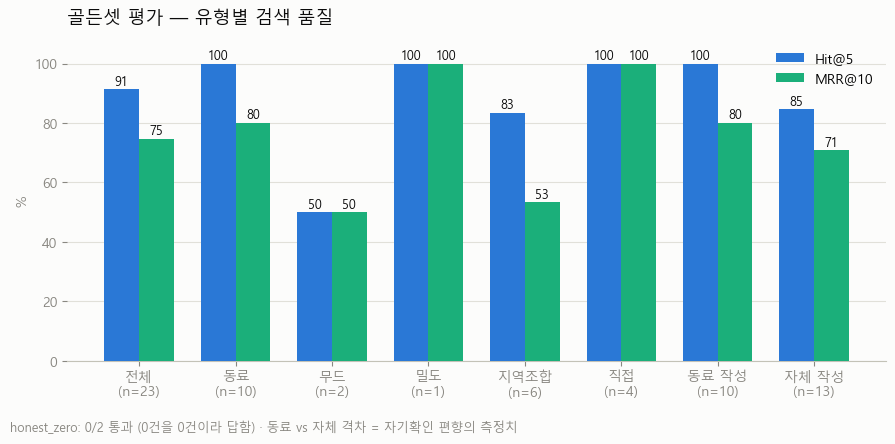

저장 → eval/골든셋_결과.png


In [6]:
# ④-a 요약 차트 — 유형별 Hit@5 / MRR@10 (그룹 막대)
if not scored:
    print("아직 그릴 수 없음 — ③ 평가가 먼저 (라벨링 → 평가 → 시각화 순서). (고장 아님)")
else:
    import matplotlib
    import matplotlib.pyplot as plt
    matplotlib.rcParams["font.family"] = "Malgun Gothic"   # Windows 한글 (mac은 AppleGothic)
    matplotlib.rcParams["axes.unicode_minus"] = False

    C_HIT, C_MRR = "#2a78d6", "#1baf7a"          # 카테고리 슬롯 1(blue)·2(aqua)
    SURF, INK, MUT, GRID, BASE = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"

    groups = ["전체"] + sorted(set(r["type"] for r in scored)) + ["동료 작성", "자체 작성"]
    def sel(g):
        if g == "전체": return scored
        if g == "동료 작성": return [r for r in scored if r["source"] == "peer"]
        if g == "자체 작성": return [r for r in scored if r["source"] == "self"]
        return [r for r in scored if r["type"] == g]
    hit = [sum(r["hit5"] for r in sel(g)) / len(sel(g)) * 100 for g in groups]
    mrr = [sum(r["rr"] for r in sel(g)) / len(sel(g)) * 100 for g in groups]
    ns  = [len(sel(g)) for g in groups]

    fig, ax = plt.subplots(figsize=(9, 4.2), facecolor=SURF)
    ax.set_facecolor(SURF)
    x = range(len(groups)); w = 0.36
    for dx, vals, c, lab in ((-w/2, hit, C_HIT, "Hit@5"), (w/2, mrr, C_MRR, "MRR@10")):
        bars = ax.bar([i + dx for i in x], vals, w, color=c, label=lab, zorder=3)
        for b in bars:   # 막대끝 수치 = aqua 대비 경고 보완 (relief rule)
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.5,
                    f"{b.get_height():.0f}", ha="center", fontsize=9, color=INK)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f"{g}\n(n={n})" for g, n in zip(groups, ns)], fontsize=10, color=INK)
    ax.set_ylim(0, 108); ax.set_ylabel("%", color=MUT)
    ax.yaxis.grid(True, color=GRID, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(BASE)
    ax.tick_params(colors=MUT)
    ax.legend(frameon=False, loc="upper right", fontsize=10)
    ax.set_title("골든셋 평가 — 유형별 검색 품질", fontsize=13, color=INK, loc="left", pad=12)
    if hz:
        fig.text(0.01, -0.04, f"honest_zero: {sum(r['hz_pass'] for r in hz)}/{len(hz)} 통과 "
                 f"(0건을 0건이라 답함) · 동료 vs 자체 격차 = 자기확인 편향의 측정치",
                 fontsize=9, color=MUT)
    plt.tight_layout()
    plt.savefig(os.path.join(ROOT, "eval", "골든셋_결과.png"), dpi=150,
                bbox_inches="tight", facecolor=SURF)
    plt.show()
    print("저장 → eval/골든셋_결과.png")

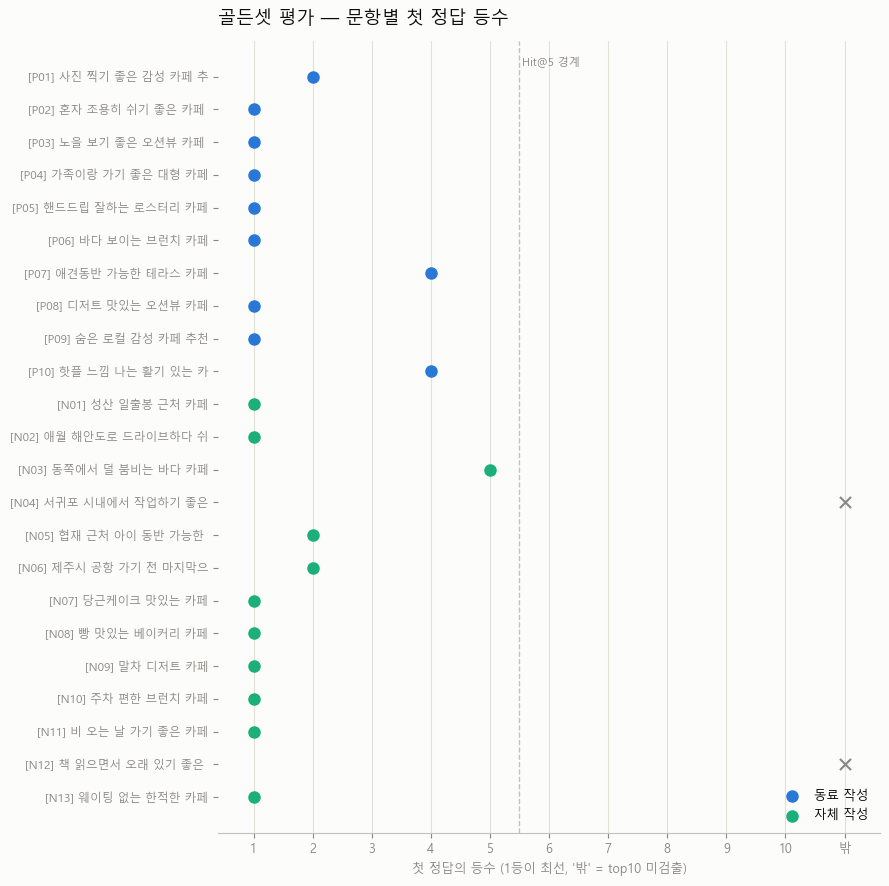

저장 → eval/골든셋_문항별.png


In [7]:
# ④-b 문항별 상세 — 첫 정답이 몇 등에 나왔나 (왼쪽일수록 좋음)
if not scored:
    print("아직 그릴 수 없음 — ③ 평가가 먼저. (고장 아님)")
else:
    import matplotlib.pyplot as plt
    C_PEER, C_SELF = "#2a78d6", "#1baf7a"        # 색 = 문항 출처 (동료/자체)
    SURF, INK, MUT, GRID, BASE = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
    MISS_X = 11                                   # top10 밖(미검출) 자리

    order = sorted(scored, key=lambda r: (r["source"] != "peer", r["qid"]))
    fig, ax = plt.subplots(figsize=(9, 0.32 * len(order) + 1.6), facecolor=SURF)
    ax.set_facecolor(SURF)
    for y, r in enumerate(order):
        rank = round(1 / r["rr"]) if r["rr"] else None    # rr = 1/첫 정답 등수
        c = C_PEER if r["source"] == "peer" else C_SELF
        if rank:
            ax.scatter(rank, y, s=64, color=c, zorder=3)
        else:
            ax.scatter(MISS_X, y, s=64, color=MUT, marker="x", zorder=3)
    ax.axvline(5.5, color=BASE, lw=1, ls="--", zorder=1)
    ax.text(5.55, -0.6, "Hit@5 경계", fontsize=8, color=MUT, va="top")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels([f"[{r['qid']}] {r['question'][:16]}" for r in order], fontsize=8.5, color=INK)
    ax.invert_yaxis()
    ax.set_xticks(list(range(1, 11)) + [MISS_X])
    ax.set_xticklabels([str(i) for i in range(1, 11)] + ["밖"], fontsize=9)
    ax.set_xlim(0.4, MISS_X + 0.6)
    ax.set_xlabel("첫 정답의 등수 (1등이 최선, '밖' = top10 미검출)", fontsize=9, color=MUT)
    ax.xaxis.grid(True, color=GRID, zorder=0); ax.set_axisbelow(True)
    for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(BASE)
    ax.tick_params(colors=MUT)
    ax.scatter([], [], s=64, color=C_PEER, label="동료 작성")
    ax.scatter([], [], s=64, color=C_SELF, label="자체 작성")
    ax.legend(frameon=False, loc="lower right", fontsize=9)
    ax.set_title("골든셋 평가 — 문항별 첫 정답 등수", fontsize=13, color=INK, loc="left", pad=12)
    plt.tight_layout()
    plt.savefig(os.path.join(ROOT, "eval", "골든셋_문항별.png"), dpi=150,
                bbox_inches="tight", facecolor=SURF)
    plt.show()
    print("저장 → eval/골든셋_문항별.png")

In [8]:
# ⑤ README용 마크다운 표 — "한계와 남은 것"의 정량 지표 부재 항목과 교체
if not scored:
    print("아직 출력할 수 없음 — ③ 평가가 먼저. (고장 아님)")
else:
    def pct(rs, key):
        vals = [r[key] for r in rs if r[key] is not None]
        return f"{sum(vals)/len(vals)*100:.1f}%" if vals else "-"
    lines = ["| 구분 | Hit@5 | MRR@10 | n |", "|---|---:|---:|---:|",
             f"| 전체 | {pct(scored,'hit5')} | {pct(scored,'rr')} | {len(scored)} |"]
    for t in sorted(set(r["type"] for r in scored)):
        rs = [r for r in scored if r["type"] == t]
        lines.append(f"| {t} | {pct(rs,'hit5')} | {pct(rs,'rr')} | {len(rs)} |")
    if hz:
        lines.append(f"| honest_zero | {sum(r['hz_pass'] for r in hz)}/{len(hz)} 통과 | - | {len(hz)} |")
    print("\n".join(lines))
    print()
    print("※ 한계: 25문항 중 15문항은 데이터 접촉자가 작성 (자기확인 편향 가능성).")
    print(f"   동료 작성 Hit@5 {pct([r for r in scored if r['source']=='peer'],'hit5')} vs "
          f"자체 작성 {pct([r for r in scored if r['source']=='self'],'hit5')} — 차이가 편향의 측정치.")

| 구분 | Hit@5 | MRR@10 | n |
|---|---:|---:|---:|
| 전체 | 91.3% | 74.8% | 23 |
| 동료 | 100.0% | 80.0% | 10 |
| 무드 | 50.0% | 50.0% | 2 |
| 밀도 | 100.0% | 100.0% | 1 |
| 지역조합 | 83.3% | 53.3% | 6 |
| 직접 | 100.0% | 100.0% | 4 |
| honest_zero | 0/2 통과 | - | 2 |

※ 한계: 25문항 중 15문항은 데이터 접촉자가 작성 (자기확인 편향 가능성).
   동료 작성 Hit@5 100.0% vs 자체 작성 84.6% — 차이가 편향의 측정치.


## 5. 결과 해석 (2026-07-12 실측)

**전체: Hit@5 91.3% · MRR@10 74.8% (n=23) — 개편 후 시스템의 첫 정량 성적.**

- **유형별**: 직접(당근케이크·말차류) 100/100, 밀도 100/100, 동료 100/80 — 태그 어휘와 닿는 질문은 사실상 다 잡는다.
  약한 축은 무드 50/50과 지역조합 83.3/53.3 — 지역조합은 잡긴 하는데 순위가 낮은 편(MRR 53.3 = 정답이 주로 2~5위).
- **실패 2건의 공통 원인 = 0건 반환** (순위 밀림이 아니라 빈손):
  - [N04] "서귀포 시내에서 **작업하기** 좋은 곳" → 번역기가 '시내에서'·'작업하기'를 unresolved 처리 → 매칭 태그 0 → 0건
  - [N12] "책 **읽으면서 오래 있기** 좋은 카페" → '읽으면서'·'오래'·'있기' 전부 unresolved → 0건
  - 조사·동사가 붙은 구어 어절을 태그로 못 푸는 지점 — 미완 백로그 **W1(태그사전 v2)** 이 정확히 여기다. 실측이 백로그 우선순위를 증명.
- **honest_zero 0/2 — 이번 평가의 가장 정직한 숫자**: "한라산 정상 근처"는 '한라산'이 태그 '한라산뷰'(유사도 0.851)로
  흡수되고 '정상'·'근처'는 조용히 버려져 한라산**뷰** 카페 5곳이 반환됐다. "24시간"도 무관한 카드 5곳이 채워졌다.
  조건을 못 풀면 빈손을 인정하는 대신 그럴듯한 것을 채우는 폴백 — "모르면 모른다"(G030 하드 배제의 정신)가
  무존재 조건까지는 아직 못 갔다.
- **동료 100% vs 자체 84.6%**: 자기확인 편향 우려와 **반대 방향** — 데이터를 본 사람의 문항이 오히려 더 어려웠다.
  동료 문항은 리뷰 코퍼스의 전형 표현(오션뷰·브런치·애견동반)이라 태그와 정합하고, 자체 문항이 구어 동사형을 섞었기 때문.
  이 격차는 "편향 없음"의 증명이 아니라 "동료 문항이 시스템 어휘에 가까웠다"로 읽는 게 정직하다.

## 6. 한계와 정직한 각주

1. **자체 작성 15문항** — 카드 데이터를 본 사람이 작성해 자기확인 편향 가능성. 동료 10문항과의 격차(100% vs 84.6%)를
   편향의 측정치로 함께 공개한다 — 이번엔 자체 문항이 오히려 더 어려웠다.
2. **기계 라벨의 순환성** — 기계 규칙 문항(P01~P10·N08·N10·N13)은 정답을 카드 **태그**로 정의했다. 검색의 주 경로도
   태그 매칭이라, 이 문항들이 재는 것은 "질의→태그 번역" 능력이지 태그 자체의 품질 오류가 아니다
   (N04·N12의 0건이 바로 그 번역 단계의 실패 사례).
3. **라벨 주체** — 지역 문항(N01~N06)은 민옥이 개별 확정, 나머지는 규칙 수준 승인 후 데이터 접촉자(코워크)가 선별.
   문항별 정답 수 편차가 큼(5~262곳).
4. **표본 n=25** — 방향 확인용이지 통계적 확정이 아님. 팀원의 Gold 50(개편 전, 저장소 밖)과는 문항·기준이 달라 직접 비교 불가.
5. **honest_zero 경계사례** — "한라산 정상 근처"에 한라산1100고지(중턱 휴게소) 카드가 존재. 본 평가는 "정상 아님 = 오답"으로 처리.
6. **시점 의존** — 카드는 2026-07 수집 스냅샷. 폐업·영업시간 변동은 이후 보장 없음.

## 마무리 체크
- [x] 결과 표를 README에 붙였다 (숫자가 낮아도 그대로 + 원인 한 줄)
- [x] 한계 문구(자체 작성 15문항·기계 라벨 순환성)를 함께 적었다
- [ ] `data/golden/questions.json`, 이 노트북, `eval/골든셋_*.png`를 커밋했다

여기까지가 프로젝트의 마지막 커밋. **측정으로 시작해서 측정으로 닫는다.**